**Program No. 11.  >> Node-Link Diagram**

**Objective:** To visualize relationships between entities. 
Tasks:
- Draw a node-link diagram showing relationships (e.g., friends in a class)

Outcome: Students can build and train basic neural networks.


**Step 1: Install NetworkX**

In [1]:
!pip install networkx

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Step 2:** Import Libraries

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

**Step 3:** Load Dataset and Prepare Network

In [3]:
# Load dataset
df = pd.read_csv("student_extended.csv")

df.columns = df.columns.str.strip().str.lower()

# Select 20 students for clean network
sample_df = df.sample(25, random_state=42)

**Step 4:** Draw Node-Link Diagram

In [4]:
G = nx.Graph()

# Add nodes with attributes
for _, row in sample_df.iterrows():
    G.add_node(
        row["roll_number"],
        department=row["department"],
        specialization=row["specialization"],
        study_hours=row["study_hours_per_day"]
    )

# Add edges based on strong relationship logic
for i in range(len(sample_df)):
    for j in range(i+1, len(sample_df)):
        
        dept_match = sample_df.iloc[i]["department"] == sample_df.iloc[j]["department"]
        spec_match = sample_df.iloc[i]["specialization"] == sample_df.iloc[j]["specialization"]
        hours_close = abs(sample_df.iloc[i]["study_hours_per_day"] -
                          sample_df.iloc[j]["study_hours_per_day"]) <= 1
        
        if dept_match and spec_match and hours_close:
            G.add_edge(
                sample_df.iloc[i]["roll_number"],
                sample_df.iloc[j]["roll_number"]
            )

In [5]:
G = nx.Graph()

# Add nodes
for _, row in sample_df.iterrows():
    G.add_node(
        row["roll_number"],
        department=row["department"],
        sgpa=row["sgpa"],
        study_hours=row["study_hours_per_day"],
        specialization=row["specialization"]
    )

# Add edges
for i in range(len(sample_df)):
    for j in range(i+1, len(sample_df)):
        
        dept_match = sample_df.iloc[i]["department"] == sample_df.iloc[j]["department"]
        spec_match = sample_df.iloc[i]["specialization"] == sample_df.iloc[j]["specialization"]
        hours_close = abs(sample_df.iloc[i]["study_hours_per_day"] -
                          sample_df.iloc[j]["study_hours_per_day"]) <= 1
        
        if dept_match and spec_match and hours_close:
            G.add_edge(
                sample_df.iloc[i]["roll_number"],
                sample_df.iloc[j]["roll_number"]
            )

**Step 4:** Professional Visualization & Generate 3D Positions

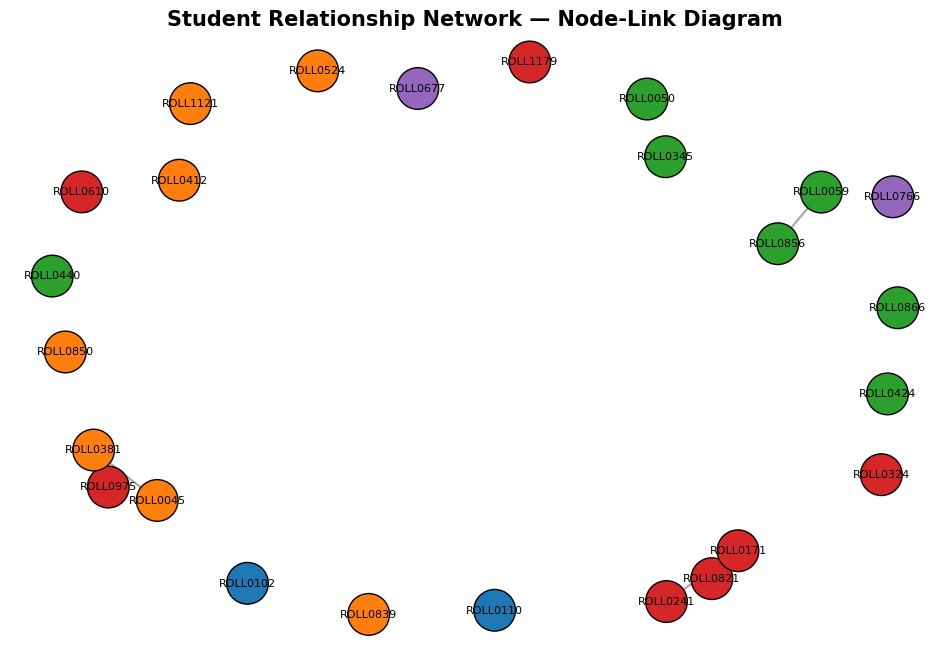

In [6]:
plt.figure(figsize=(12,8))

# Better layout
pos = nx.spring_layout(G, k=0.5, seed=42)

# Color nodes by department
departments = list(set(sample_df["department"]))
color_map = {dept: plt.cm.tab10(i) for i, dept in enumerate(departments)}

node_colors = [
    color_map[G.nodes[node]["department"]]
    for node in G.nodes
]

nx.draw_networkx_nodes(
    G, pos,
    node_size=900,
    node_color=node_colors,
    edgecolors="black"
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    width=1.5,
    alpha=0.7
)

nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title("Student Relationship Network — Node-Link Diagram",
          fontsize=15,
          fontweight="bold")

plt.axis("off")
plt.show()

In [7]:
pos_2d = nx.spring_layout(G, seed=42)

# Convert to 3D by adding random Z depth
pos_3d = {node: (pos_2d[node][0],
                 pos_2d[node][1],
                 np.random.uniform(-0.5, 0.5))
          for node in G.nodes()}

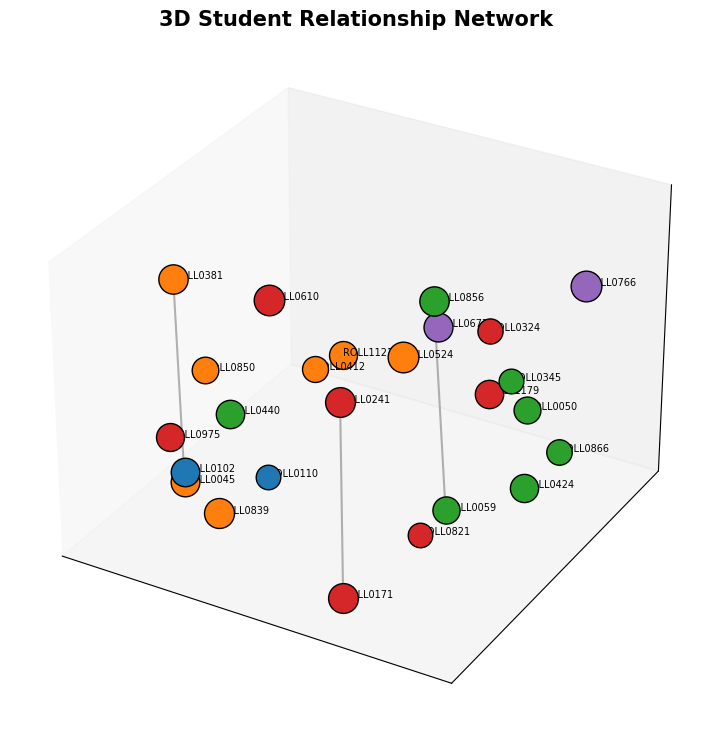

In [8]:
fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

# Color mapping by department
departments = list(set(sample_df["department"]))
color_map = {dept: plt.cm.tab10(i) for i, dept in enumerate(departments)}

for node in G.nodes():
    x, y, z = pos_3d[node]
    dept = G.nodes[node]["department"]
    sgpa = G.nodes[node]["sgpa"]
    
    ax.scatter(
        x, y, z,
        s=sgpa * 50,   # node size based on SGPA
        color=color_map[dept],
        edgecolors='black'
    )
    
    ax.text(x, y, z, node, fontsize=7)

# Draw edges
for edge in G.edges():
    x_vals = [pos_3d[edge[0]][0], pos_3d[edge[1]][0]]
    y_vals = [pos_3d[edge[0]][1], pos_3d[edge[1]][1]]
    z_vals = [pos_3d[edge[0]][2], pos_3d[edge[1]][2]]
    
    ax.plot(x_vals, y_vals, z_vals, color='gray', alpha=0.6)

ax.set_title("3D Student Relationship Network", fontsize=15, fontweight="bold")

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.show()

The Node-Link Diagram represents relationships between students based on department membership.

Each node corresponds to a student, and an edge connects two students if they belong to the same department. This creates clusters within the network graph that represent departmental groupings.

**This type of visualization is useful for:**
- Social network analysis
- Academic grouping visualization
- Community detection
- Understanding relationship structures

The spring layout algorithm positions nodes based on connection strength, creating a visually intuitive representation of clusters.